# V7 Changes
## Altered model parameters and criterions


# Setup

## Set up notebook environment by importing libraries, defining centralized preprocessing configuration, and building the list of EMG data files to load.

## V3 EDITS: Added class 7 to dropped labels

## V5 EDITS: Increased step size from 25 to 75 to address overfitting.

In [2]:
from __future__ import annotations

import os
import json
import math
import re
import random
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class PreprocessingConfig:
    """
    Stores configuration parameters for preprocessing and window creation.
    """

    # Windowing parameters
    window_size: int = 600
    step_size: int = 600

    # Number of windows to extract from each cleaned phase
    rest_windows_per_phase: int = 1
    gesture_windows_per_phase: int = 2

    # Dataset timing
    sample_rate_hz: int = 500
    phase_seconds: int = 3

    # Trim this many seconds from the start and end of each phase to avoid transition artifacts
    boundary_trim_seconds: float = 0.5

    # Search a small positive offset at the beginning of each file to better align the repeating 3s gesture pattern
    phase_offset_search_step: int = 25        
    phase_offset_search_max_abs_seconds: float = 1.0

    # Keep rows ordered by time
    sort_by_time: bool = True


cfg = PreprocessingConfig()

# Calculate derived parameters
phase_samples = cfg.sample_rate_hz * cfg.phase_seconds
boundary_trim_samples = int(cfg.boundary_trim_seconds * cfg.sample_rate_hz)

# Define the root directory containing the CSV files
root_dir = Path("./subject_data")

# Recursively find all CSV files in the root directory and its subdirectories
DATA_FILES = sorted([file for file in root_dir.rglob("*.csv")])

# Define columns and gestures to exclude from the dataset
DROP_COLUMNS = {
    "GyroX", "GyroY", "GyroZ",
    "AccX", "AccY", "AccZ",
    "PPG1", "PPG2",
    "rawPPG1", "rawPPG2", "rawPPG3",
    "Hr", "Hrv",
    "Battery",
    "Trigger", "PhysicalTrigger", "AutoTrigger"
}
EXCLUDED_GESTURES = {"2F"}#, "3F", "Pro", "Sup"}

# Print out the configuration and dataset information for verification
print("Number of files found:", len(DATA_FILES))
if len(DATA_FILES) > 0:
    print("Example file:", DATA_FILES[0])
print("Samples per 3-second phase:", phase_samples)
print("Boundary trim per side:", boundary_trim_samples, "samples")

Number of files found: 160
Example file: subject_data\subject_1\Subject1_2F_3s.csv
Samples per 3-second phase: 1500
Boundary trim per side: 250 samples


# Load Files

## Load all EMG files into Pandas DataFrames, standarize column names, and concatenate them into one single dataset.

In [3]:
def load_emg_file(path: str | Path) -> pd.DataFrame:
    """
    Load one EMG CSV file from the dataset.
    """
    path = Path(path)
    df = pd.read_csv(path, sep="\t", engine="python")
    return df


def normalize_gesture_label(raw_label: str) -> str:
    """
    Normalize file-derived gesture labels.
    """
    label = str(raw_label).strip()
    if label.lower().startswith("rest"):
        return "Rest"
    return label


def parse_subject_and_gesture(path: str | Path) -> tuple[str, str]:
    """
    Parse subject ID and gesture label from the file path.
    """
    path = Path(path)

    subject_id = path.parent.name
    stem = path.stem

    parts = stem.split("_")
    if len(parts) < 2:
        raise ValueError(f"Could not parse gesture from filename: {path.name}")

    gesture_parts = parts[1:]

    if len(gesture_parts) >= 2 and gesture_parts[-1].lower() == "3s":
        gesture_parts = gesture_parts[:-1]

    if len(gesture_parts) == 0:
        raise ValueError(f"Could not parse gesture from filename: {path.name}")

    gesture_label = "_".join(gesture_parts)
    gesture_label = normalize_gesture_label(gesture_label)

    return subject_id, gesture_label


def infer_filtered_channel_cols(df: pd.DataFrame) -> list[str]:
    """
    Dynamically find filtered EMG columns
    """
    filtered_cols = [col for col in df.columns if col.lower().startswith("filteredchannel")]

    def sort_key(name: str):
        m = re.search(r"(\d+)$", name)
        return int(m.group(1)) if m else float("inf")

    filtered_cols = sorted(filtered_cols, key=sort_key)

    if len(filtered_cols) == 0:
        raise ValueError(
            "No filtered EMG columns found. Expected columns like FilteredChannel1, FilteredChannel2, ..."
        )

    return filtered_cols


all_dfs = []
schemas = []

for file in DATA_FILES:
    df = load_emg_file(file)
    subject_id, file_gesture_label = parse_subject_and_gesture(file)

    if file_gesture_label in EXCLUDED_GESTURES:
        continue

    cols_to_drop = [col for col in DROP_COLUMNS if col in df.columns]
    if len(cols_to_drop) > 0:
        df = df.drop(columns=cols_to_drop)

    channel_cols = infer_filtered_channel_cols(df)

    keep_cols = channel_cols.copy()
    if "Timestamp" in df.columns:
        keep_cols = ["Timestamp"] + keep_cols

    df = df[keep_cols].copy()

    if "Timestamp" in df.columns:
        df = df.rename(columns={"Timestamp": "time"})
    else:
        df["time"] = np.arange(len(df), dtype=np.int64)

    df = df[["time"] + channel_cols].copy()

    df["source_file"] = str(file)
    df["subject_id"] = subject_id
    df["file_gesture_label"] = file_gesture_label
    df["source_index"] = np.arange(len(df), dtype=np.int64)

    if cfg.sort_by_time and "time" in df.columns:
        df = df.sort_values("time", kind="mergesort").reset_index(drop=True)

    all_dfs.append(df)

    schemas.append({
        "file": str(file),
        "subject_id": subject_id,
        "file_gesture_label": file_gesture_label,
        "num_rows": len(df),
        "n_channels": len(channel_cols),
        "channels": channel_cols,
        "time_dtype": str(df["time"].dtype),
    })

raw_df = pd.concat(all_dfs, ignore_index=True)
schemas_df = pd.DataFrame(schemas)

channel_cols = infer_filtered_channel_cols(raw_df)

print("raw_df shape:", raw_df.shape)
print("Detected filtered EMG channels:", channel_cols)
print("Unique file-level labels:", sorted(raw_df["file_gesture_label"].unique().tolist()))
display(schemas_df.head())
display(raw_df.head())

raw_df shape: (4128287, 13)
Detected filtered EMG channels: ['FilteredChannel1', 'FilteredChannel2', 'FilteredChannel3', 'FilteredChannel4', 'FilteredChannel5', 'FilteredChannel6', 'FilteredChannel7', 'FilteredChannel8']
Unique file-level labels: ['3F', 'Extend', 'Fist', 'Flex', 'Pro', 'Radial', 'Rest', 'Sup', 'Ulnar']


,file,subject_id,file_gesture_label,num_rows,n_channels,channels,time_dtype
0,subject_data\subject_1\Subject1_3F_3s.csv,subject_1,3F,30812,8,"[FilteredChannel1, FilteredChannel2, FilteredC...",float64
1,subject_data\subject_1\Subject1_Extend_3s.csv,subject_1,Extend,30019,8,"[FilteredChannel1, FilteredChannel2, FilteredC...",float64
2,subject_data\subject_1\Subject1_Fist_3s.csv,subject_1,Fist,30070,8,"[FilteredChannel1, FilteredChannel2, FilteredC...",float64
3,subject_data\subject_1\Subject1_Flex_3s.csv,subject_1,Flex,29952,8,"[FilteredChannel1, FilteredChannel2, FilteredC...",float64
4,subject_data\subject_1\Subject1_Pro_3s.csv,subject_1,Pro,30060,8,"[FilteredChannel1, FilteredChannel2, FilteredC...",float64


,time,FilteredChannel1,FilteredChannel2,FilteredChannel3,FilteredChannel4,FilteredChannel5,FilteredChannel6,FilteredChannel7,FilteredChannel8,source_file,subject_id,file_gesture_label,source_index
0,1.775714e+09,2.456277,1.839171,1.774819,0.969128,3.859907,3.128963,0.806072,2.660677,subject_data\subject_1\Subject1_3F_3s.csv,subject_1,3F,0
1,1.775714e+09,1.806763,1.581684,2.265252,0.765263,1.414242,-6.931321,-1.305462,0.843921,subject_data\subject_1\Subject1_3F_3s.csv,subject_1,3F,1
2,1.775714e+09,-0.575829,-0.612545,0.188169,-1.216144,-2.895496,-11.684240,-2.410448,-2.026418,subject_data\subject_1\Subject1_3F_3s.csv,subject_1,3F,2
3,1.775714e+09,-3.883048,-4.232368,-4.123742,-4.731417,-7.918094,-5.807925,-2.025128,-4.910020,subject_data\subject_1\Subject1_3F_3s.csv,subject_1,3F,3
4,1.775714e+09,-5.474548,-6.257459,-7.023900,-6.728982,-10.457941,3.291287,-0.806362,-5.706948,subject_data\subject_1\Subject1_3F_3s.csv,subject_1,3F,4


# Verify Proprocessing parameters

In [4]:
filtered_df = raw_df.copy()

print("Using pre-filtered EMG channels from the files.")
print("Using known device sampling rate:", cfg.sample_rate_hz, "Hz")
print("Samples per 3-second phase:", phase_samples)
print("Boundary trim per side:", boundary_trim_samples, "samples")

Using pre-filtered EMG channels from the files.
Using known device sampling rate: 500 Hz
Samples per 3-second phase: 1500
Boundary trim per side: 250 samples


# Check for Invalid Labels

## Check for missing labels that can break segmentation, label encoding, and loss computation.

In [5]:
def report_missing_file_labels(df: pd.DataFrame):
    """
    Verify that every row belongs to a file with a known file-level gesture label.
    """
    bad = df[df["file_gesture_label"].isna()]
    print("Total rows:", len(df))
    print("Rows with missing file_gesture_label:", len(bad))

    if len(bad) > 0:
        print("\nMissing file_gesture_label rows by file:")
        print(bad["source_file"].value_counts())
        display(bad.head(10))


report_missing_file_labels(filtered_df)

Total rows: 4128287
Rows with missing file_gesture_label: 0


# Re-Segment and Window

## Convert continous EMG recordings into fixed length training samples using label-based segmentation and a sliding window.

In [6]:
def get_phase_label(file_gesture_label: str, phase_index: int) -> str:
    """
    Determine the label of a 3-second phase inside a file.
    """
    file_gesture_label = normalize_gesture_label(file_gesture_label)

    if file_gesture_label == "Rest":
        return "Rest"

    return "Rest" if phase_index % 2 == 0 else file_gesture_label


def compute_emg_energy(segment: np.ndarray) -> float:
    """
    Compute average RMS energy for an EMG segment/window.
    Higher values usually indicate stronger muscle activation.
    """
    if len(segment) == 0:
        return 0.0

    rms_per_channel = np.sqrt(np.mean(np.square(segment), axis=0))
    return float(np.mean(rms_per_channel))


def compute_phase_energy(segment: np.ndarray) -> float:
    return compute_emg_energy(segment)


def find_best_phase_offset(
    df: pd.DataFrame,
    channel_cols: list[str],
    phase_samples: int,
    cfg: PreprocessingConfig
) -> int:
    """
    Search a small positive offset to better align the repeating
    3s rest / 3s gesture structure.
    """
    file_gesture_label = normalize_gesture_label(str(df["file_gesture_label"].iloc[0]))
    if file_gesture_label == "Rest":
        return 0

    data = df[channel_cols].to_numpy(dtype=np.float32)
    n = len(data)

    max_offset = min(
        int(cfg.phase_offset_search_max_abs_seconds * cfg.sample_rate_hz),
        max(0, phase_samples - 1)
    )

    candidate_offsets = list(range(0, max_offset + 1, cfg.phase_offset_search_step))
    if len(candidate_offsets) == 0:
        return 0

    best_offset = 0
    best_score = -np.inf

    for offset in candidate_offsets:
        num_complete_phases = (n - offset) // phase_samples
        if num_complete_phases < 2:
            continue

        energies = []
        for phase_idx in range(num_complete_phases):
            start = offset + phase_idx * phase_samples
            end = start + phase_samples
            segment = data[start:end]
            energies.append(compute_phase_energy(segment))

        rest_energies = np.array(energies[0::2], dtype=np.float32)
        gesture_energies = np.array(energies[1::2], dtype=np.float32)

        if len(rest_energies) == 0 or len(gesture_energies) == 0:
            continue

        score = float(np.mean(gesture_energies) - np.mean(rest_energies))

        if score > best_score:
            best_score = score
            best_offset = offset

    return int(best_offset)


def split_file_into_phases(
    df: pd.DataFrame,
    channel_cols: list[str],
    phase_samples: int,
    cfg: PreprocessingConfig
) -> List[pd.DataFrame]:
    """
    Split one file into consecutive 3-second phases after first estimating a small alignment offset.
    """
    phases = []

    file_gesture_label = normalize_gesture_label(str(df["file_gesture_label"].iloc[0]))
    subject_id = str(df["subject_id"].iloc[0])
    source_file = str(df["source_file"].iloc[0])

    best_offset = find_best_phase_offset(df, channel_cols, phase_samples, cfg)

    n = len(df)
    num_complete_phases = (n - best_offset) // phase_samples

    for phase_idx in range(num_complete_phases):
        start = best_offset + phase_idx * phase_samples
        end = start + phase_samples

        phase = df.iloc[start:end].copy().reset_index(drop=True)
        phase["label"] = get_phase_label(file_gesture_label, phase_idx)
        phase["phase_index"] = phase_idx
        phase["subject_id"] = subject_id
        phase["source_file"] = source_file
        phase["file_gesture_label"] = file_gesture_label
        phase["best_offset"] = best_offset

        phases.append(phase)

    return phases


def make_windows_from_phase(
    phase_df: pd.DataFrame,
    channel_cols: list[str],
    cfg: PreprocessingConfig,
    rest_energy_threshold: float | None = None,
    gesture_energy_multiplier: float = 1.25
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create clean windows from the middle of a labeled phase.
    """
    trim = int(cfg.boundary_trim_seconds * cfg.sample_rate_hz)

    if len(phase_df) <= 2 * trim:
        return (
            np.empty((0, cfg.window_size, len(channel_cols)), dtype=np.float32),
            np.empty((0,), dtype=object)
        )

    core_df = phase_df.iloc[trim: len(phase_df) - trim].reset_index(drop=True)
    data = core_df[channel_cols].to_numpy(dtype=np.float32)
    label = str(core_df["label"].iloc[0])

    T, C = data.shape

    if T < cfg.window_size:
        return (
            np.empty((0, cfg.window_size, C), dtype=np.float32),
            np.empty((0,), dtype=object)
        )

    max_start = T - cfg.window_size

    if label == "Rest":
        starts = [(T - cfg.window_size) // 2]

    else:
        candidate_step = max(1, cfg.window_size // 10)
        candidate_starts = list(range(0, max_start + 1, candidate_step))

        if max_start not in candidate_starts:
            candidate_starts.append(max_start)

        scored_starts = []

        for s in candidate_starts:
            window = data[s:s + cfg.window_size]
            energy = compute_emg_energy(window)
            scored_starts.append((energy, s))

        scored_starts = sorted(scored_starts, reverse=True)

        starts = []

        for energy, s in scored_starts:
            if rest_energy_threshold is not None:
                if energy < gesture_energy_multiplier * rest_energy_threshold:
                    continue

            too_close = any(abs(s - existing_s) < cfg.window_size // 2 for existing_s in starts)

            if not too_close:
                starts.append(s)

            if len(starts) >= cfg.gesture_windows_per_phase:
                break

        starts = sorted(starts)

    if len(starts) == 0:
        return (
            np.empty((0, cfg.window_size, C), dtype=np.float32),
            np.empty((0,), dtype=object)
        )

    X = np.stack([data[s:s + cfg.window_size] for s in starts], axis=0).astype(np.float32)
    y = np.array([label] * len(starts), dtype=object)

    return X, y


all_phases = []

for source_file, sub in filtered_df.groupby("source_file", sort=False):
    sub = sub.reset_index(drop=True)
    phases = split_file_into_phases(sub, channel_cols, phase_samples, cfg)
    all_phases.extend(phases)

print("Number of 3-second phases found:", len(all_phases))

rest_window_energies = []

for phase_df in all_phases:
    label = str(phase_df["label"].iloc[0])

    if label != "Rest":
        continue

    trim = int(cfg.boundary_trim_seconds * cfg.sample_rate_hz)

    if len(phase_df) <= 2 * trim:
        continue

    core_df = phase_df.iloc[trim: len(phase_df) - trim].reset_index(drop=True)
    data = core_df[channel_cols].to_numpy(dtype=np.float32)

    if len(data) < cfg.window_size:
        continue

    start = (len(data) - cfg.window_size) // 2
    window = data[start:start + cfg.window_size]

    rest_window_energies.append(compute_emg_energy(window))

rest_energy_threshold = np.percentile(rest_window_energies, 95)

print("Rest windows used to estimate threshold:", len(rest_window_energies))
print("95th percentile Rest energy threshold:", rest_energy_threshold)

X_list = []
y_list = []
file_list = []
subject_list = []

dropped_phase_count = 0
kept_window_count = 0

for phase_df in all_phases:
    expected_label = str(phase_df["label"].iloc[0])

    X_phase, y_phase = make_windows_from_phase(
        phase_df,
        channel_cols,
        cfg,
        rest_energy_threshold=rest_energy_threshold,
        gesture_energy_multiplier=1.25
    )

    if len(y_phase) == 0:
        if expected_label != "Rest":
            dropped_phase_count += 1
        continue

    kept_window_count += len(y_phase)

    X_list.append(X_phase)
    y_list.append(y_phase)
    file_list.extend([phase_df["source_file"].iloc[0]] * len(y_phase))
    subject_list.extend([phase_df["subject_id"].iloc[0]] * len(y_phase))

print("Gesture phases dropped because they looked too much like Rest:", dropped_phase_count)
print("Total windows kept:", kept_window_count)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
files = np.array(file_list)
subjects = np.array(subject_list)

print(f"Final dataset shape: X={X.shape}, y={y.shape}")
print("Window label distribution:")
print(pd.Series(y).value_counts().sort_index())
print("Number of unique subjects:", len(np.unique(subjects)))

Number of 3-second phases found: 2682
Rest windows used to estimate threshold: 1449
95th percentile Rest energy threshold: 12.127250289916992
Gesture phases dropped because they looked too much like Rest: 636
Total windows kept: 2445
Final dataset shape: X=(2445, 600, 8), y=(2445,)
Window label distribution:
3F          93
Extend     254
Fist       234
Flex        93
Pro         42
Radial     167
Rest      1449
Sup         16
Ulnar       97
Name: count, dtype: int64
Number of unique subjects: 16


# Train/Validation/Test Split Without Leakage

## Split the dataset into train/validation/test in a way that prevents leakage by ensuring windows from the same file do not appear in multiple splits.

In [40]:
from sklearn.model_selection import train_test_split


def split_by_subject(
    subjects: np.ndarray,
    train_size: float = 0.7,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = random.randint(1,100)
) -> tuple[set[str], set[str], set[str]]:
    """
    Split by unique subject IDs so windows from the same subject do not appear in multiple splits.
    """
    unique_subjects = np.unique(subjects)

    train_subjects, temp_subjects = train_test_split(
        unique_subjects,
        test_size=1 - train_size,
        random_state=random_state,
        shuffle=True
    )

    val_subjects, test_subjects = train_test_split(
        temp_subjects,
        test_size=test_size / (test_size + val_size),
        random_state=random_state,
        shuffle=True
    )

    return set(train_subjects), set(val_subjects), set(test_subjects)


train_subjects, val_subjects, test_subjects = split_by_subject(subjects)

train_mask = np.array([s in train_subjects for s in subjects])
val_mask = np.array([s in val_subjects for s in subjects])
test_mask = np.array([s in test_subjects for s in subjects])

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train subjects:", sorted(train_subjects))
print("Val subjects:", sorted(val_subjects))
print("Test subjects:", sorted(test_subjects))

Train: (1796, 600, 8) Val: (260, 600, 8) Test: (389, 600, 8)
Train subjects: ['subject_1', 'subject_10', 'subject_11', 'subject_14', 'subject_15', 'subject_18', 'subject_2', 'subject_4', 'subject_5', 'subject_6', 'subject_8']
Val subjects: ['subject_16', 'subject_3']
Test subjects: ['subject_17', 'subject_7', 'subject_9']


In [8]:
def rebalance_training_split(
    X_train: np.ndarray,
    y_train: np.ndarray,
    random_state: int = random.randint(1,100),
    rest_multiplier: float = 2.0
) -> tuple[np.ndarray, np.ndarray]:
    """
    Rebalance the training set by downsampling Rest only.
    """
    rng = np.random.default_rng(random_state)

    classes = sorted(np.unique(y_train).tolist())
    class_to_indices = {cls: np.where(y_train == cls)[0] for cls in classes}

    non_rest_classes = [cls for cls in classes if cls != "Rest"]
    non_rest_counts = [len(class_to_indices[cls]) for cls in non_rest_classes]

    if len(non_rest_counts) == 0:
        return X_train, y_train

    median_non_rest = int(np.median(non_rest_counts))
    median_non_rest = max(median_non_rest, 1)

    selected_indices = []

    for cls in classes:
        idxs = class_to_indices[cls]

        if cls == "Rest":
            target = int(round(rest_multiplier * median_non_rest))
            target = min(target, len(idxs))
            chosen = rng.choice(idxs, size=target, replace=False)
        else:
            chosen = idxs

        selected_indices.append(chosen)

    selected_indices = np.concatenate(selected_indices)
    rng.shuffle(selected_indices)

    return X_train[selected_indices], y_train[selected_indices]


print("Before rebalancing:")
print(pd.Series(y_train).value_counts().sort_index())

X_train, y_train = rebalance_training_split(
    X_train,
    y_train,
    random_state=random.randint(1,100),
    rest_multiplier=2.0
)

print("\nAfter rebalancing:")
print(pd.Series(y_train).value_counts().sort_index())
print("Rebalanced X_train shape:", X_train.shape)

Before rebalancing:
3F         78
Extend    170
Fist      155
Flex       50
Pro        42
Radial    113
Rest      999
Sup        16
Ulnar      69
Name: count, dtype: int64

After rebalancing:
3F         78
Extend    170
Fist      155
Flex       50
Pro        42
Radial    113
Rest      146
Sup        16
Ulnar      69
Name: count, dtype: int64
Rebalanced X_train shape: (839, 600, 8)


# Encode Labels Dynamically

## Convert raw label values into consecutive class indices (0...K-1) required by PyTorch classification.

In [9]:
def create_label_mapping(labels: np.ndarray) -> Dict[str, int]:
    """
    Create mapping from string class names to integer class indices.
    """
    unique_labels = sorted(np.unique(labels).tolist())
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    return label_to_index


label_map = create_label_mapping(y_train)
inv_label_map = {idx: label for label, idx in label_map.items()}


def encode_labels(labels: np.ndarray, label_map: Dict[str, int]) -> np.ndarray:
    """
    Encode string labels into integer class IDs.
    """
    return np.array([label_map[label] for label in labels], dtype=np.int64)


y_train_encoded = encode_labels(y_train, label_map)
y_val_encoded = encode_labels(y_val, label_map)
y_test_encoded = encode_labels(y_test, label_map)

num_classes = len(label_map)

print("num_classes:", num_classes)
print("label_map:", label_map)

num_classes: 9
label_map: {'3F': 0, 'Extend': 1, 'Fist': 2, 'Flex': 3, 'Pro': 4, 'Radial': 5, 'Rest': 6, 'Sup': 7, 'Ulnar': 8}


# Normalize

## Normalize EMG channels so each channel has a consistent scale. This improves training stability and helps the model learn patterns instead of absolute magnitudes.

In [10]:
def fit_channel_standardizer(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Fit a channel-wise standardizer to the input data X by calculating the mean and standard deviation for each channel across all samples and time steps.
    """

    # Reshape the data to combine the samples and time steps into a single dimension
    flat = X.reshape(-1, X.shape[-1])

    # Calculate the mean and standard deviation for each channel, adding a small epsilon to the standard deviation to prevent division by zero during standardization.
    mean = np.mean(flat, axis = 0)
    std = np.std(flat, axis = 0) + 1e-8
    return mean.astype(np.float32), std.astype(np.float32)

def apply_channel_standardization(X: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """
    Apply channel-wise standardization to the input data X using the provided mean and standard deviation for each channel.
    """

    return ((X - mean[None, None, :]) / std[None, None, :]).astype(np.float32)

# Fit the channel standardizer on the training data
mean_std = fit_channel_standardizer(X_train)

# Apply the channel standardization to the training, validation, and test sets
X_train_n = apply_channel_standardization(X_train, *mean_std)
X_val_n = apply_channel_standardization(X_val, *mean_std)
X_test_n = apply_channel_standardization(X_test, *mean_std)

# Print the shapes of the normalized training, validation, and test datasets
print("Normalized shapes:", X_train_n.shape, X_val_n.shape, X_test_n.shape)

Normalized shapes: (839, 600, 8) (253, 600, 8) (500, 600, 8)


# Create Custom Dataset

## Wrap the windowed EMG arrays and labels into a PyTorch Dataset so they can be efficiently loaded in batches during training.

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader

class EMGWindowsDataset(Dataset):
    """
    A PyTorch Dataset for EMG windows.
    """

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        augment: bool = False,
        noise_std: float = 0.001,
        gain_jitter_std: float = 0.02
    ):
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples")

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

        self.augment = augment
        self.noise_std = noise_std
        self.gain_jitter_std = gain_jitter_std

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]

        if self.augment:
            # Add very small Gaussian noise
            x = x + torch.randn_like(x) * self.noise_std

            # Add very small per-channel amplitude jitter
            gains = 1.0 + torch.randn(x.shape[1]) * self.gain_jitter_std
            gains = gains.to(x.device)
            x = x * gains.unsqueeze(0)

        return x, y

# Create DataLoaders

## Create PyTorch DataLoaders to batch and shuffle data during training and evaluation.

## V2 EDIT: Added a weighted random sampler to address class imbalance.

## V5 EDIT: Removed the use of WeightedRandomSample due to no class imbalance after dropping label 7.

In [12]:
from torch.utils.data import DataLoader

batch_size = 32

train_dataset = EMGWindowsDataset(
    X_train_n,
    y_train_encoded,
    augment=True,
    noise_std=0.001,
    gain_jitter_std=0.02
)

val_dataset = EMGWindowsDataset(
    X_val_n,
    y_val_encoded,
    augment=False
)

test_dataset = EMGWindowsDataset(
    X_test_n,
    y_test_encoded,
    augment=False
)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
class_counts = torch.bincount(y_train_tensor, minlength=num_classes).float()
class_counts = torch.clamp(class_counts, min=1.0)

class_weights = 1.0 / torch.sqrt(class_counts)
class_weights = class_weights / class_weights.mean()

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.tolist())

Train batches: 27
Val batches: 8
Test batches: 16
Class counts: [78.0, 170.0, 155.0, 50.0, 42.0, 113.0, 146.0, 16.0, 69.0]
Class weights: [0.9154322147369385, 0.6200817823410034, 0.6493930220603943, 1.1433744430541992, 1.2475236654281616, 0.7605613470077515, 0.6691092252731323, 2.021219491958618, 0.9733049273490906]


# Extract Dynamic Model Parameters

## Automatically derive key model parameters from the prepared data so the model matches the dataset.

In [13]:
# Extract the number of channels, sequence length, and number of classes from the training data 
num_channels = X_train_n.shape[2]
sequence_length = X_train_n.shape[1]
num_classes = len(np.unique(y_train_encoded))

# Print the number of channels, sequence length, and number of classes 
print("num_channels:", num_channels)
print("sequence_length:", sequence_length)
print("num_classes:", num_classes)

num_channels: 8
sequence_length: 600
num_classes: 9


# Define CNN-LSTM Classifier

## Define the CNN-LSTM nerual network used to classify each EMG window into a gesture class.

## V2 EDIT: Added dropout in the final classifier to reduce overfitting.

## V4 EDIT: Converted from pure LSTM to CNN-LSTM hyrbid.

In [14]:
import torch.nn as nn

class CNNLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        conv_channels: list[int] | tuple[int, ...] = (64, 128),
        kernel_size: int = 7,
        lstm_hidden_size: int = 128,
        lstm_num_layers: int = 2,
        dropout: float = 0.3,
        bidirectional: bool = True,
    ):
        """
        Initiate the CNNLSTMClassifier with the specified architecture parameters, including the input size (number of channels), number of output classes, convolutional layer configuration, LSTM configuration, dropout rate, and whether to use bidirectional LSTMs.
        """
        
        # Call the superclass constructor to initialize the nn.Module
        super().__init__()

        # Store the parameters as instance variables
        self.input_size = input_size
        self.num_classes = num_classes
        self.conv_channels = list(conv_channels)
        self.kernel_size = kernel_size
        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_num_layers = lstm_num_layers
        self.dropout = dropout
        self.bidirectional = bidirectional

        # CNN expects shape: (batch, channels, time)
        conv_layers = []
        in_channels = input_size

        # Build the convolutional layers based on the specified configuration
        for i, out_channels in enumerate(self.conv_channels):
            # Each convolutional layer consists of a Conv1d, followed by BatchNorm1d, ReLU activation, and MaxPool1d to reduce the temporal dimension. 
            conv_layers.extend([
                nn.Conv1d(
                    in_channels = in_channels,
                    out_channels = out_channels,
                    kernel_size = kernel_size,
                    padding = kernel_size // 2
                ),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5)
            ])

            # Only pool once, after the first conv block
            if i == 0:
                conv_layers.append(nn.MaxPool1d(kernel_size=2, stride=2))

            # Update in_channels for the next layer to be the out_channels of the current layer
            in_channels = out_channels
        
        # Combine the convolutional layers into a sequential module
        self.cnn = nn.Sequential(*conv_layers)

        # LSTM input size becomes the final number of CNN output channels
        self.lstm = nn.LSTM(
            input_size = in_channels,
            hidden_size = lstm_hidden_size,
            num_layers = lstm_num_layers,
            batch_first = True,
            dropout = dropout if lstm_num_layers > 1 else 0.0,
            bidirectional = bidirectional
        )

        lstm_output_size = lstm_hidden_size * (2 if bidirectional else 1)

        # avg pool + max pool => 2 * lstm_output_size
        self.head = nn.Sequential(
            nn.Linear(lstm_output_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, num_channels)

        # CNN expects (batch, channels, time)
        x = x.transpose(1, 2)

        # CNN feature extraction
        x = self.cnn(x)

        # Back to LSTM shape: (batch, seq_len, features)
        x = x.transpose(1, 2)

        # LSTM output for every time step
        lstm_out, _ = self.lstm(x)

        # Global average pooling over time
        avg_pool = torch.mean(lstm_out, dim=1)

        # Global max pooling over time
        max_pool, _ = torch.max(lstm_out, dim=1)

        # Combine both summaries
        features = torch.cat([avg_pool, max_pool], dim=1)

        logits = self.head(features)
        return logits

# Instantiate the Model

## Create an instance of the CNN-LSTM model using the dataset-derived dimensions and chosen hyperparameters.

## V4 EDIT: Updated parameters for CNN-LSTM

In [15]:
# Extract the number of channels and sequence length
num_channels = X_train_n.shape[2]
sequence_length = X_train_n.shape[1]

print("num_channels:", num_channels)
print("sequence_length:", sequence_length)
print("num_classes:", num_classes)

conv_channels = [48, 96]
kernel_size = 7
lstm_hidden_size = 96
lstm_num_layers = 1
dropout = 0.25
bidirectional = True

model = CNNLSTMClassifier(
    input_size=num_channels,
    num_classes=num_classes,
    conv_channels=conv_channels,
    kernel_size=kernel_size,
    lstm_hidden_size=lstm_hidden_size,
    lstm_num_layers=lstm_num_layers,
    dropout=dropout,
    bidirectional=bidirectional
)

num_channels: 8
sequence_length: 600
num_classes: 9


# Create Device, Loss Function, and Optimizer

## Configure training compoents: move the model to CPU/GPU, define the classification loss, and choose an optimizer to update weights.

## V2 EDITS: Used AdamW and LR scheduler instead of Adam to improve generalization.

## V5 EDITS: Change optimizer and scheduler parameters to improve performance.

In [16]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=0.02
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("Using device:", device)

Using device: cpu


# Sanity Check

## Run a quick forward pass on one batch to verify shapes, data types, and that the model can produce outputs without crashing.

In [17]:
# Test the forward pass of the model with a single batch of data from the training DataLoader
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)
logits = model(X_batch)

# Print the shapes of the input batch, labels, and output logits
print("X_batch:", X_batch.shape)   
print("y_batch:", y_batch.shape)    
print("logits:", logits.shape) 

X_batch: torch.Size([32, 600, 8])
y_batch: torch.Size([32])
logits: torch.Size([32, 9])


# Training and Validation Utilities

## Define reusable helper functions for training and validation.

## V2 EDITS: Added gradient clipping to stabilize LSTM training.

In [18]:
from sklearn.metrics import f1_score

def train_one_epoch(model: nn.Module, dataloader: DataLoader, criterion, optimizer, device) -> dict:
    """
    Train the model for one epoch.
    """
    model.train()

    total_loss = 0.0
    total_correct = 0.0
    total_count = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y_batch).sum().item()
        total_count += batch_size

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count
    }


@torch.no_grad()
def evaluate(model: nn.Module, dataloader: DataLoader, criterion, device) -> dict:
    """
    Evaluate the model and return loss, accuracy, and macro-F1.
    """
    model.eval()

    total_loss = 0.0
    total_correct = 0.0
    total_count = 0

    all_preds = []
    all_labels = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        total_correct += (preds == y_batch).sum().item()
        total_count += batch_size

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
        "macro_f1": macro_f1
    }

# Full Training Loop

## Train the model for multiple epochs while tracking validation performance and saving the best model weights.

## V2 EDITS: Added an early stopping mechanism and utilized a learning rate scheduler to address overfitting and improve generalization.

## V5 EDITS: Increased patience for model to benefit from lower learning rate.

In [19]:
import copy
import math

max_epochs = 80
patience = 8
best_val_macro_f1 = -math.inf
best_model_state = None
epochs_no_improve = 0
history = []

for epoch in range(1, max_epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device) if len(val_loader) > 0 else None

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"]
    }

    if val_metrics is not None:
        row["val_loss"] = val_metrics["loss"]
        row["val_accuracy"] = val_metrics["accuracy"]
        row["val_macro_f1"] = val_metrics["macro_f1"]

        scheduler.step(val_metrics["macro_f1"])

        if val_metrics["macro_f1"] > best_val_macro_f1 + 1e-4:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch}: "
            f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['accuracy']:.4f}, "
            f"Val Loss={val_metrics['loss']:.4f}, Val Acc={val_metrics['accuracy']:.4f}, "
            f"Val MacroF1={val_metrics['macro_f1']:.4f}, "
            f"NoImprove={epochs_no_improve}/{patience}"
        )

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {patience} epochs with no macro-F1 improvement")
            break

    else:
        print(
            f"Epoch {epoch}: "
            f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['accuracy']:.4f}"
        )

    history.append(row)

Epoch 1: Train Loss=2.1375, Train Acc=0.2813, Val Loss=2.0390, Val Acc=0.7115, Val MacroF1=0.1962, NoImprove=0/8
Epoch 2: Train Loss=1.9904, Train Acc=0.3754, Val Loss=1.4414, Val Acc=0.7154, Val MacroF1=0.1835, NoImprove=1/8
Epoch 3: Train Loss=1.7980, Train Acc=0.4434, Val Loss=1.1221, Val Acc=0.7470, Val MacroF1=0.3184, NoImprove=0/8
Epoch 4: Train Loss=1.6309, Train Acc=0.5077, Val Loss=1.1965, Val Acc=0.7510, Val MacroF1=0.2707, NoImprove=1/8
Epoch 5: Train Loss=1.4695, Train Acc=0.5697, Val Loss=1.1041, Val Acc=0.7668, Val MacroF1=0.3080, NoImprove=2/8
Epoch 6: Train Loss=1.2860, Train Acc=0.6281, Val Loss=1.3475, Val Acc=0.7431, Val MacroF1=0.2530, NoImprove=3/8
Epoch 7: Train Loss=1.1743, Train Acc=0.6627, Val Loss=1.0729, Val Acc=0.7628, Val MacroF1=0.2905, NoImprove=4/8
Epoch 8: Train Loss=1.0627, Train Acc=0.6937, Val Loss=0.9070, Val Acc=0.7826, Val MacroF1=0.3360, NoImprove=0/8
Epoch 9: Train Loss=1.0112, Train Acc=0.7247, Val Loss=0.8861, Val Acc=0.8261, Val MacroF1=0.406

# Load Best Model Weights

## Restore the best-performing model parameters found during training before testing.

In [20]:
# Load that best model state back into the model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded Best Model With Best Val Macro F1={best_val_macro_f1:.4f}")

Loaded Best Model With Best Val Macro F1=0.6113


# Evaluate on Test Set

## Compute final loss and accuracy on the held-out test set using the best model weights.

In [21]:
# Evaluate the final model on the test set
test_metrics = evaluate(model, test_loader, criterion, device)

print(
    f"Test Loss={test_metrics['loss']:.4f}, "
    f"Test Acc={test_metrics['accuracy']:.4f}, "
    f"Test MacroF1={test_metrics['macro_f1']:.4f}"
)

Test Loss=0.8741, Test Acc=0.8020, Test MacroF1=0.4590


# Evaluate Model Performance

## Produce deeper evaluation outputs to understand where the model succeeds or fail.

              precision    recall  f1-score   support

          3F     0.0000    0.0000    0.0000        15
      Extend     0.7000    0.9655    0.8116        58
        Fist     0.5875    0.9216    0.7176        51
        Flex     0.4231    0.4074    0.4151        27
         Pro     0.0000    0.0000    0.0000         0
      Radial     1.0000    0.1176    0.2105        51
        Rest     0.9244    0.9963    0.9590       270
         Sup     0.0000    0.0000    0.0000         0
       Ulnar     0.8000    0.4286    0.5581        28

    accuracy                         0.8020       500
   macro avg     0.4928    0.4263    0.4080       500
weighted avg     0.8099    0.8020    0.7603       500



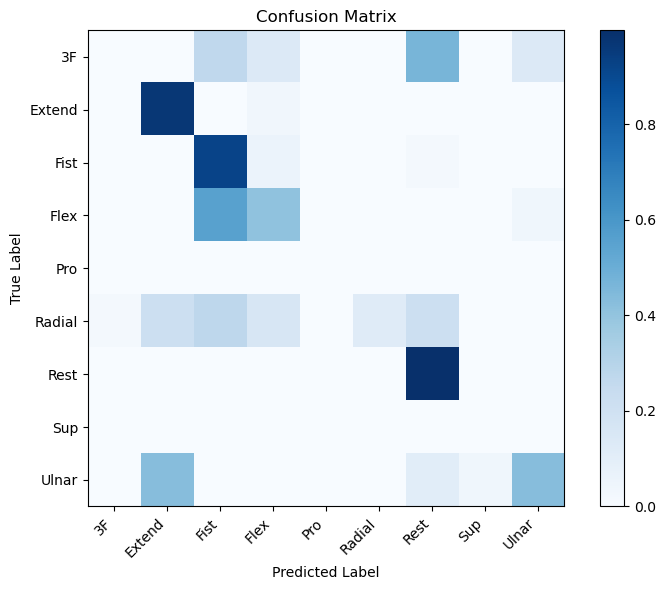

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def evaluate_full(model: nn.Module, dataloader: DataLoader, device):
    """
    Evaluate the model on a full dataloader and return encoded true/pred labels.
    """
    model.eval()

    all_preds = []
    all_labels = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(y_batch.numpy())

    return np.concatenate(all_labels), np.concatenate(all_preds)


y_true, y_pred = evaluate_full(model, test_loader, device)

target_names = [inv_label_map[i] for i in range(num_classes)]

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
    target_names=target_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize = "true")

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, target_names, rotation=45, ha="right")
plt.yticks(tick_marks, target_names)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Check Class Imbalance

## Inspect how many samples exist per class in the training set to identify imbalance that could hurt performance.

In [23]:
# Print the distribution of encoded labels in the training set 
print(pd.Series(y_train_encoded).value_counts().sort_index())

0     78
1    170
2    155
3     50
4     42
5    113
6    146
7     16
8     69
Name: count, dtype: int64


# Plot Training Curves

## Visualize training/validation loss and accuracy across epochs to diagnose overfitting or underfitting.

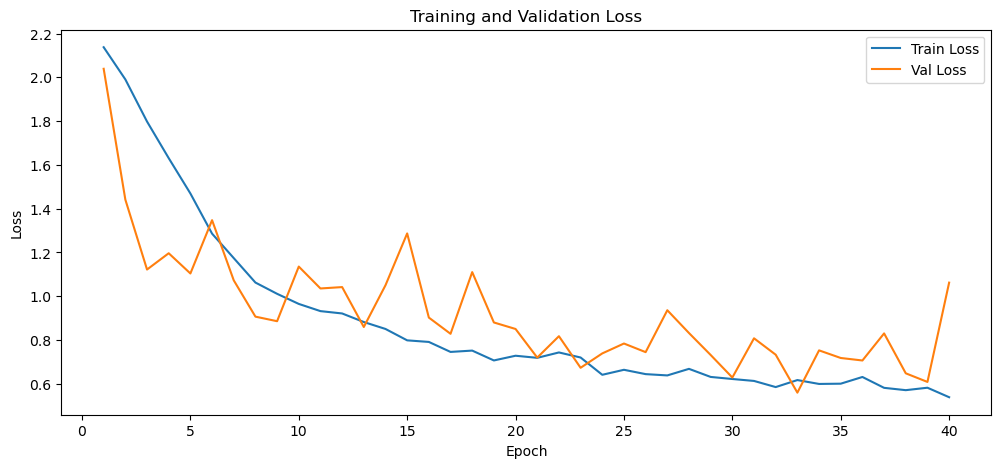

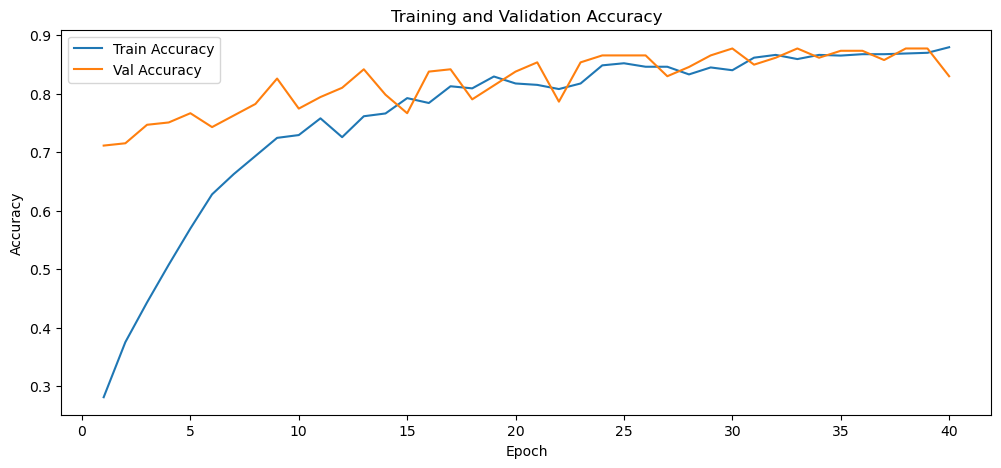

In [24]:
# Convert the training history into a DataFram
hist = pd.DataFrame(history)

# Plot the training and validation loss over epochs
plt.figure(figsize = (12, 5))
plt.plot(hist["epoch"], hist["train_loss"], label = "Train Loss")
if "val_loss" in hist.columns:
    plt.plot(hist["epoch"], hist["val_loss"], label = "Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# Plot the training and validation accuracy over epochs
plt.figure(figsize = (12, 5))
plt.plot(hist["epoch"], hist["train_accuracy"], label = "Train Accuracy")
if "val_accuracy" in hist.columns:
    plt.plot(hist["epoch"], hist["val_accuracy"], label = "Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

# Save the Model

## Save the trained model and the preprocessing metadata needed to correctly use it later.

In [25]:
# Save the best model state and metadata to the artifacts directory 
out = Path("artifacts")
out.mkdir(exist_ok = True)
torch.save(best_model_state, out / "best_model_v8.pt")

# Gather the metadata about the dataset and label mapping
meta = {
    "window_len": cfg.window_size,
    "step_size": cfg.step_size,
    "sample_rate_hz": cfg.sample_rate_hz,
    "phase_seconds": cfg.phase_seconds,
    "phase_samples": phase_samples,
    "num_channels": num_channels,
    "num_classes": num_classes,
    "channel_columns": channel_cols,
    "label_map": label_map,
    "inverted_label_map": {str(k): v for k, v in inv_label_map.items()},
}

# Store the metadata as a JSON file in the artifacts directory
with open(out / "metadata_v8.json", "w") as f:
    json.dump(meta, f, indent = 2)

# Print the path to the saved model and metadata
print("Saved model and metadata to", out.resolve())


Saved model and metadata to C:\Users\Ahuma\Desktop\CS180\EMGTuner-master\artifacts
